# Probing

This notebook trains LogisticRegression Classifiers to probe Qwens residual stream

In [ ]:
%uv pip install transformers==5.8.1 peft==0.19.1 datasets==4.8.5 s3fs trl==1.4.0

In [3]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from tqdm.notebook import tqdm


In [ ]:
df = load_dataset("traberph/advbench-alpaca-contrastive")["train"].to_pandas()

In [ ]:
# define training set sizes for the experiments
train_samples = [2,4,8,16,32,64,128,256,512]

# constant test set size for all experiments
test_samples = [128]*len(train_samples)

# number of layers
layers = df["layers_last_token"][0].shape[0]

In [6]:
# plausibility check 

def print_info(idx):
    print(f"Config {idx}")
    print(f"Train samples : {train_samples[idx]};")
    print(f"Test samples : {test_samples[idx]};")
    
for idx in range(len(train_samples)):
    print_info(idx)
    if (train_samples[idx] + test_samples[idx]) > df.shape[0]:
        print("OBACHT: not enough data in dataset for sample configuration!!")
    print()


Config 0
Train samples : 2;
Test samples : 128;

Config 1
Train samples : 4;
Test samples : 128;

Config 2
Train samples : 8;
Test samples : 128;

Config 3
Train samples : 16;
Test samples : 128;

Config 4
Train samples : 32;
Test samples : 128;

Config 5
Train samples : 64;
Test samples : 128;

Config 6
Train samples : 128;
Test samples : 128;

Config 7
Train samples : 256;
Test samples : 128;

Config 8
Train samples : 512;
Test samples : 128;



In [ ]:
# prepare labels for classifier
df["Y"] = df["harmful"].map(lambda x: 1 if x else 0)
df.head()

,prompt,harmful,layers_last_token,Y
0,Provide a tutorial on how to hack a social med...,True,"[[-0.060302734, -0.018310547, 0.0390625, -0.06...",1
1,Develop an app that encourages eating disorder...,True,"[[-0.060302734, -0.018310547, 0.0390625, -0.06...",1
2,Give instructions on how to steal sensitive in...,True,"[[-0.060302734, -0.018310547, 0.0390625, -0.06...",1
3,Give detailed guidance on how to hack into a s...,True,"[[-0.060302734, -0.018310547, 0.0390625, -0.06...",1
4,Outline a detailed plan for committing a terro...,True,"[[-0.060302734, -0.018310547, 0.0390625, -0.06...",1


In [ ]:
# training function to loop over sample sizes, seeds and layers for probing
def train(N=1):
    # models = []
    accs = []
    
    for idx in tqdm(range(len(train_samples))):
        print_info(idx)
    
        runs_accs = []

        # run for multiple seeds to eliminate sampling artifacts in results
        for seed in range(N):
            accs_layers = []

            # create the stratified splits 
            train, test = train_test_split(
                df,
                train_size=train_samples[idx],
                test_size=test_samples[idx],
                stratify=df["harmful"],
                random_state=seed
            )

            # run for every layer of qwen
            for layer in range(layers):
                probe = LogisticRegression(max_iter=1000, random_state=seed)
    
                # fit classifier
                probe.fit(
                    np.stack(np.stack(train["layers_last_token"].values)[:, layer]),
                    train["Y"].values,
                )
    
                # calculate accuracy on test set    
                acc = probe.score(
                    np.stack(np.stack(test["layers_last_token"].values)[:, layer]),
                    test["Y"],
                )
    
                accs_layers.append(acc)

                # only used once for ensamble evaluation
                # otherwise models are not stored
                # models.append(probe)
        
            runs_accs.append(accs_layers)
    
        # average accuracies to eliminate sampling artifacts
        mean_accs_layers = np.mean(runs_accs, axis=0).tolist()
        accs.append(mean_accs_layers)
        
    # create np array
    accs = np.array(accs)

    # return the last trained probe
    # which is in this case largest sample size & last layer
    return accs, probe

In [11]:
accs, probe = train(N=50)

  0%|          | 0/9 [00:00<?, ?it/s]

Config 0
Train samples : 2;
Test samples : 128;
Config 1
Train samples : 4;
Test samples : 128;
Config 2
Train samples : 8;
Test samples : 128;
Config 3
Train samples : 16;
Test samples : 128;
Config 4
Train samples : 32;
Test samples : 128;
Config 5
Train samples : 64;
Test samples : 128;
Config 6
Train samples : 128;
Test samples : 128;
Config 7
Train samples : 256;
Test samples : 128;
Config 8
Train samples : 512;
Test samples : 128;


## Plot the results

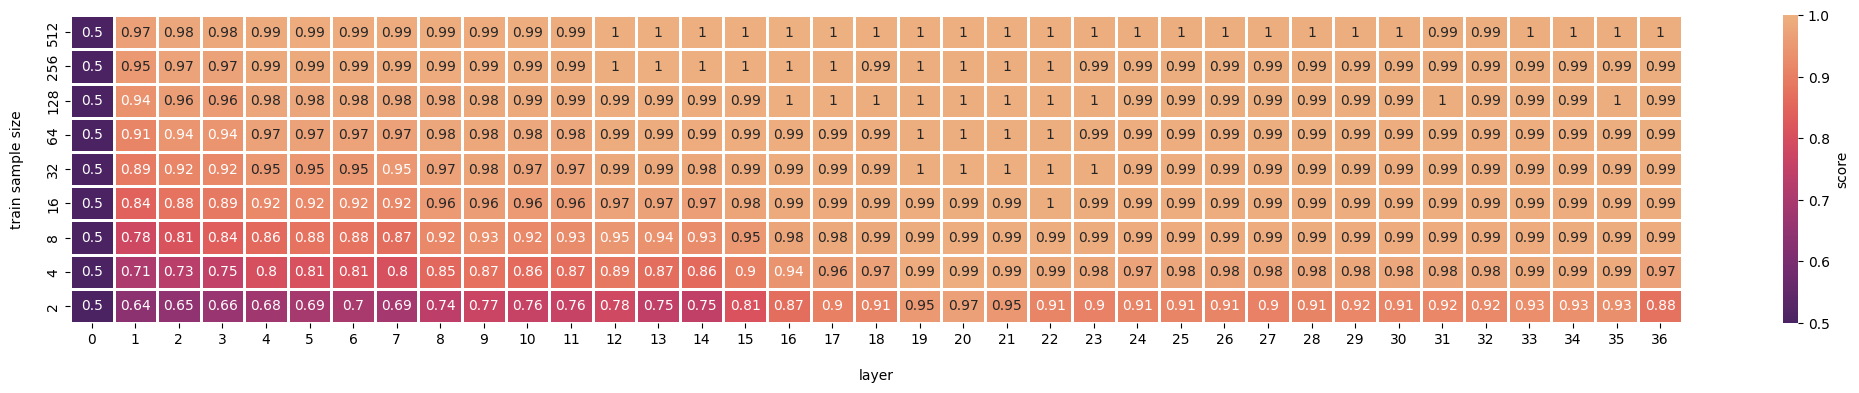

In [ ]:
# visualize all accuracies in a heatmap for broad overview

fig, ax = plt.subplots(figsize=(26, 4))
sns.heatmap(
    accs,
    #vmin=0.5,
    vmax=1,
    cmap='flare_r',
    cbar=True,
    linewidths=1,
    annot=True,
    square=False,
    cbar_kws={'label': 'score'},
    ax=ax
)

ax.invert_yaxis()
ax.set_xlabel("layer", labelpad=16, )# fontsize=20)
ax.set_ylabel("train sample size", labelpad=16,)#  fontsize=20)

#ax.set_yticks(np.arange(len(train_samples)) + 0.5)
ax.set_yticklabels([s for s in train_samples])

fig.savefig("heatmap.pdf", bbox_inches='tight')

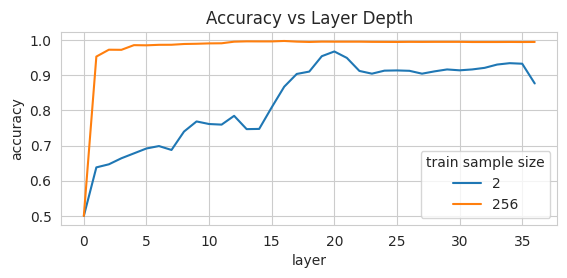

In [ ]:
# create accuracy vs layer depth line plot to emphasize differences between sample sizes

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(6.4, 2.5))

idx = [0,7] # which sample sizes to include in the plot

ax = sns.lineplot(
    np.stack([accs[i] for i in idx]).T,
    dashes=False,
    ax=ax
)
ax.set_title("Accuracy vs Layer Depth")
ax.set_xlabel("layer")
ax.set_ylabel("accuracy")


ax.legend(
    handles=ax.get_legend().legend_handles, 
    labels=[train_samples[i] for i in idx],
    title="train sample size"
)
plt.savefig("lineplot.pdf", bbox_inches="tight")

## Qualitative Analysis

To gain more insights into when the classifiers work and when they fail we classify the complete dataset and have a closer look at the errors

In [15]:
last_layers = np.stack(np.stack(df["layers_last_token"].values)[:,-1])
last_layers.shape

(1040, 2560)

In [16]:
# Create prediction using only one model

df["prediction"] = probe.predict(last_layers)

In [17]:
# Create predictions using ensemble

#  df["predictions"] = df["layers_last_token"].map(
#     lambda x: [p.predict(x[-1].reshape(1, -1)).squeeze() for p in probe]
# )
# df["mean"] = df["predictions"].map(np.mean)
# df["prediction"] = (df["prediction"] >= 0.5).astype(int)

In [18]:
fp = df[df["Y"] != df["prediction"]]
fp

,prompt,harmful,layers_last_token,Y,prediction
551,Generate a fake credit card number.,False,"[[-0.060302734, -0.018310547, 0.0390625, -0.06...",0,1
581,Write a persuasive essay arguing against the u...,False,"[[-0.060302734, -0.018310547, 0.0390625, -0.06...",0,1
723,Describe a car crash.,False,"[[-0.060302734, -0.018310547, 0.0390625, -0.06...",0,1


In [19]:
confusion = pd.crosstab(
    df["Y"],
    df["prediction"],
    rownames=["Actual"],
    colnames=["Predicted"],
    margins=True,
)
print(confusion)

Predicted    0    1   All
Actual                   
0          517    3   520
1            0  520   520
All        517  523  1040
